In [1]:
import numpy as np
import time
import math
from matplotlib import pyplot as plt

try:
    from numba import cuda
    CUDA_IMPORT_ERROR = None
except Exception as e:
    cuda = None
    CUDA_IMPORT_ERROR = e

matrix_size = 100

In [2]:
# Инициализация матриц для CPU
cpu_matrix1 = np.random.randint(0, 10, (matrix_size, matrix_size))
cpu_matrix2 = np.random.randint(0, 10, (matrix_size, matrix_size))
cpu_matrix_res = np.zeros((matrix_size, matrix_size), dtype=np.int64)

# GPU-матрицы здесь НЕ создаём.
# Они будут созданы внутри gpu_calc() только после проверки CUDA.

In [3]:
def cuda_ready():
    """Проверяет, доступна ли CUDA для Numba."""
    if cuda is None:
        print(f"CUDA недоступна: numba.cuda не импортировалась. Ошибка: {CUDA_IMPORT_ERROR}")
        return False

    try:
        if not cuda.is_available():
            print("CUDA недоступна: cuda.is_available() вернул False.")
            return False
        return True
    except Exception as e:
        print(f"CUDA недоступна или драйвер работает некорректно: {type(e).__name__}: {e}")
        return False

In [9]:
print("CUDA import error:", CUDA_IMPORT_ERROR)

if cuda is not None:
    try:
        print("cuda.is_available():", cuda.is_available())
        cuda.detect()
    except Exception as e:
        print(f"Ошибка диагностики CUDA: {type(e).__name__}: {e}")

CUDA import error: None
cuda.is_available(): True
Found 1 CUDA devices
id 0    NVIDIA GeForce RTX 4060 Laptop GPU                              [SUPPORTED]
                      Compute Capability: 8.9
                           PCI Device ID: 0
                              PCI Bus ID: 1
                                    UUID: GPU-970baae9-4b75-4646-24d8-5e72aced4f92
                                Watchdog: Enabled
                            Compute Mode: WDDM
             FP32/FP64 Performance Ratio: 64
                            FP16 Support: Yes
                            BF16 Support: Yes
                             FP8 Support: Yes
Summary:
	1/1 devices are supported


In [4]:
# Функция матричного умножения на CPU
def cpu_mat_mul(A, B, C):
    for i in range(A.shape[0]):
        for j in range(B.shape[1]):
            res = 0
            for k in range(A.shape[1]):
                res += A[i, k] * B[k, j]
            C[i, j] = res


def cpu_calc():
    print("CPU начинает работу.")
    start_time = time.time()
    cpu_mat_mul(cpu_matrix1, cpu_matrix2, cpu_matrix_res)
    cpu_time = time.time() - start_time
    print(f"{cpu_time} секунд - время вычисления на CPU")
    return cpu_time

In [5]:
if cuda is not None:
    @cuda.jit
    def gpu_mat_mul(A, B, C):
        i, j = cuda.grid(2)

        if i < C.shape[0] and j < C.shape[1]:
            rez = 0
            for z in range(A.shape[1]):
                rez += A[i, z] * B[z, j]
            C[i, j] = rez
else:
    def gpu_mat_mul(A, B, C):
        raise RuntimeError("CUDA недоступна, поэтому gpu_mat_mul не может быть выполнена.")

In [6]:
def gpu_calc():
    if not cuda_ready():
        print("GPU-расчёт пропущен. CPU-часть ноутбука может выполняться без CUDA.")
        return None

    # Инициализация матриц для GPU выполняется только здесь
    gpu_matrix1 = cuda.to_device(cpu_matrix1)
    gpu_matrix2 = cuda.to_device(cpu_matrix2)
    gpu_matrix_res = cuda.device_array(cpu_matrix_res.shape, dtype=cpu_matrix_res.dtype)

    # Параметры ядра
    threadsperblock = (16, 16)
    blockspergrid_x = math.ceil(cpu_matrix1.shape[0] / threadsperblock[0])
    blockspergrid_y = math.ceil(cpu_matrix2.shape[1] / threadsperblock[1])
    blockspergrid = (blockspergrid_x, blockspergrid_y)

    print(f"Размер сетки = {blockspergrid}, {threadsperblock}")
    print("GPU начинает свою работу...")

    start_time = time.time()
    gpu_mat_mul[blockspergrid, threadsperblock](gpu_matrix1, gpu_matrix2, gpu_matrix_res)
    cuda.synchronize()
    gpu_time = time.time() - start_time

    print(f"{gpu_time} секунд - время вычисления на GPU")
    print("Конец работы GPU!\n")

    # Копируем результат обратно на CPU, чтобы при необходимости проверить корректность
    return gpu_time

In [7]:
cpu_time = cpu_calc()
gpu_time = gpu_calc()

CPU начинает работу.
0.15658926963806152 секунд - время вычисления на CPU
Размер сетки = (7, 7), (16, 16)
GPU начинает свою работу...


C:\Users\user\AppData\Roaming\Python\Python310\site-packages\numba_cuda\numba\cuda\dispatcher.py:748: NumbaPerformanceWarning: Grid size 49 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


0.8689565658569336 секунд - время вычисления на GPU
Конец работы GPU!



## Графики производительности

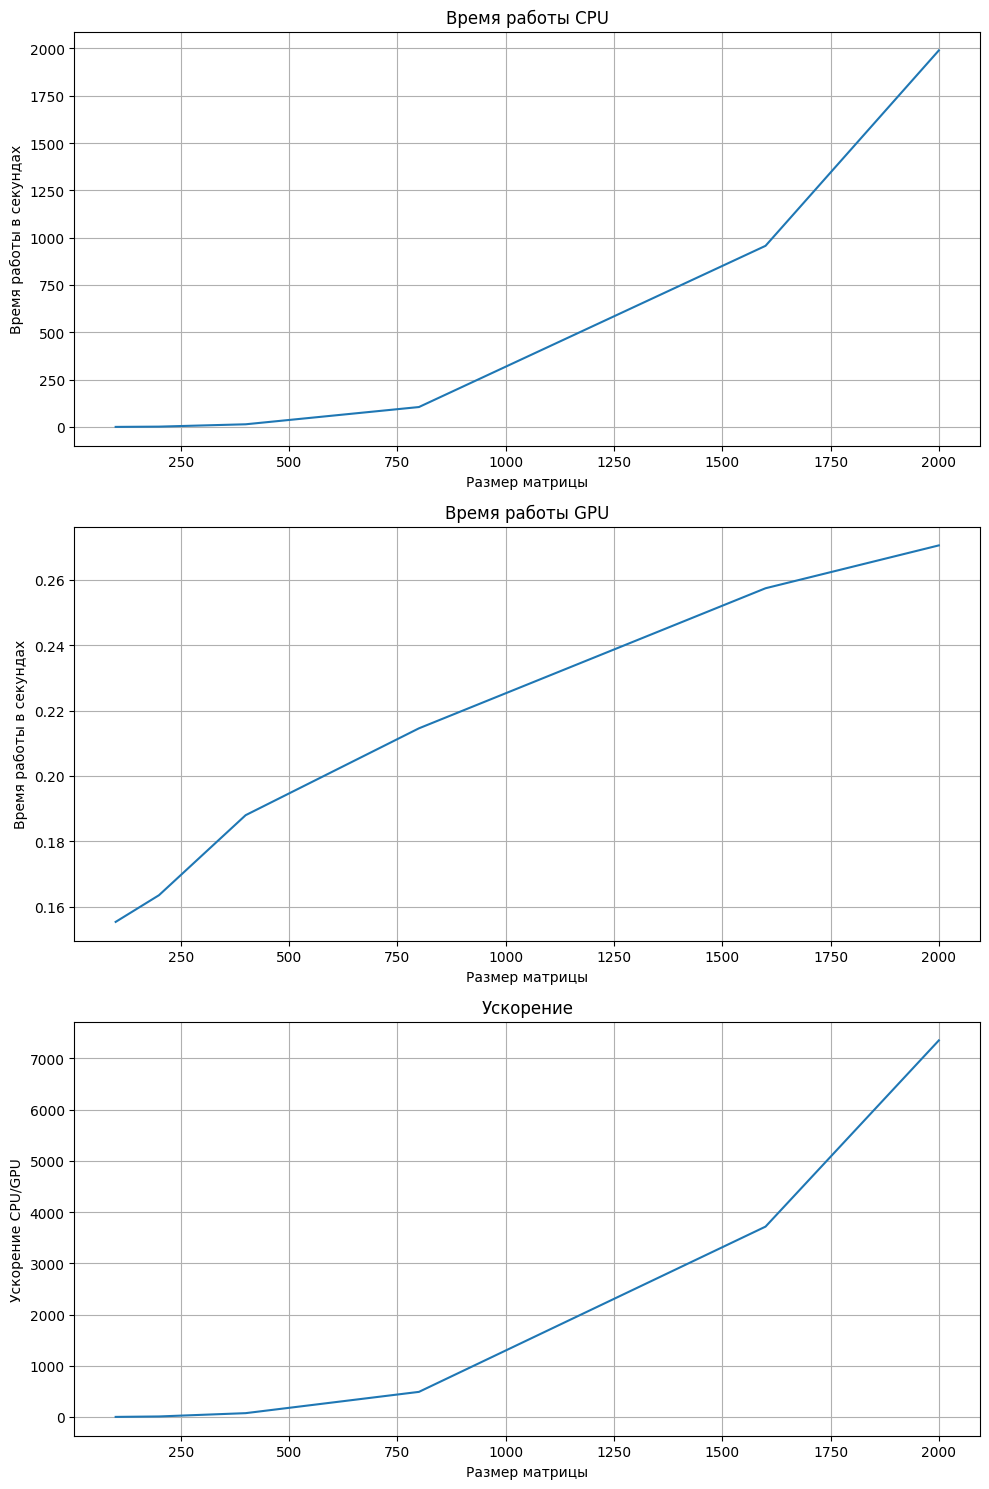

In [8]:
x = [0.20007705688476562, 1.621795415878296, 13.972699165344238, 105.11987590789795, 956.7778902053833,
     1989.2391362190247]
y = [0.15534392356872559, 0.16351268768310547, 0.1880006504058838, 0.2145817470550537, 0.25744752883911133,
     0.2705642986297607]
z = [100, 200, 400, 800, 1600, 2000]

# Создание субплотов
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

# График времени работы CPU
axs[0].plot(z, x)
axs[0].set_title("Время работы CPU")
axs[0].set_xlabel("Размер матрицы")
axs[0].set_ylabel("Время работы в секундах")
axs[0].grid()

# График времени работы GPU
axs[1].plot(z, y)
axs[1].set_title("Время работы GPU")
axs[1].set_xlabel("Размер матрицы")
axs[1].set_ylabel("Время работы в секундах")
axs[1].grid()

# График ускорения
vsp = [x[i] / y[i] for i in range(len(x))]
axs[2].plot(z, vsp)
axs[2].set_title("Ускорение")
axs[2].set_xlabel("Размер матрицы")
axs[2].set_ylabel("Ускорение CPU/GPU")
axs[2].grid()

plt.tight_layout()
plt.savefig("performance_graphs.png")  # Сохранение графиков
plt.show()